<a href="https://colab.research.google.com/github/anex4real/Assignment-1/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**3**

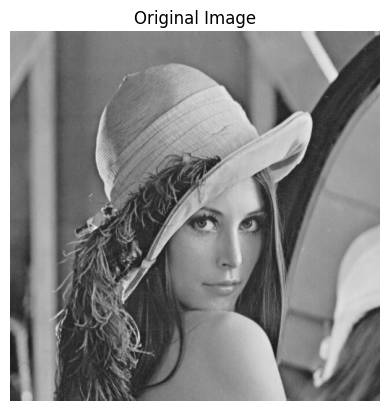

N=2: SNR = 13.96 dB
N=3: SNR = 21.82 dB
N=4: SNR = 28.60 dB
N=5: SNR = 34.97 dB
N=6: SNR = 41.16 dB
N=7: SNR = 47.88 dB
N=8: SNR = inf dB


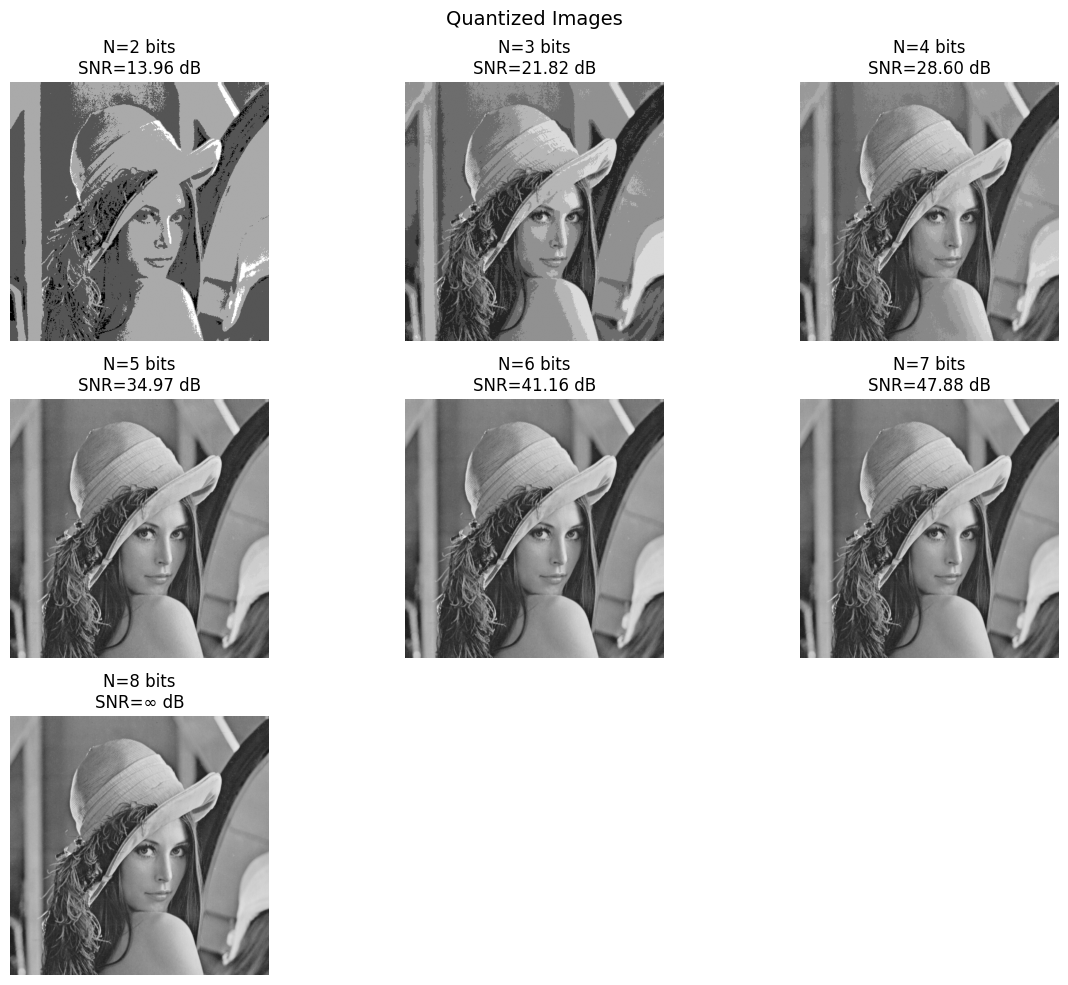

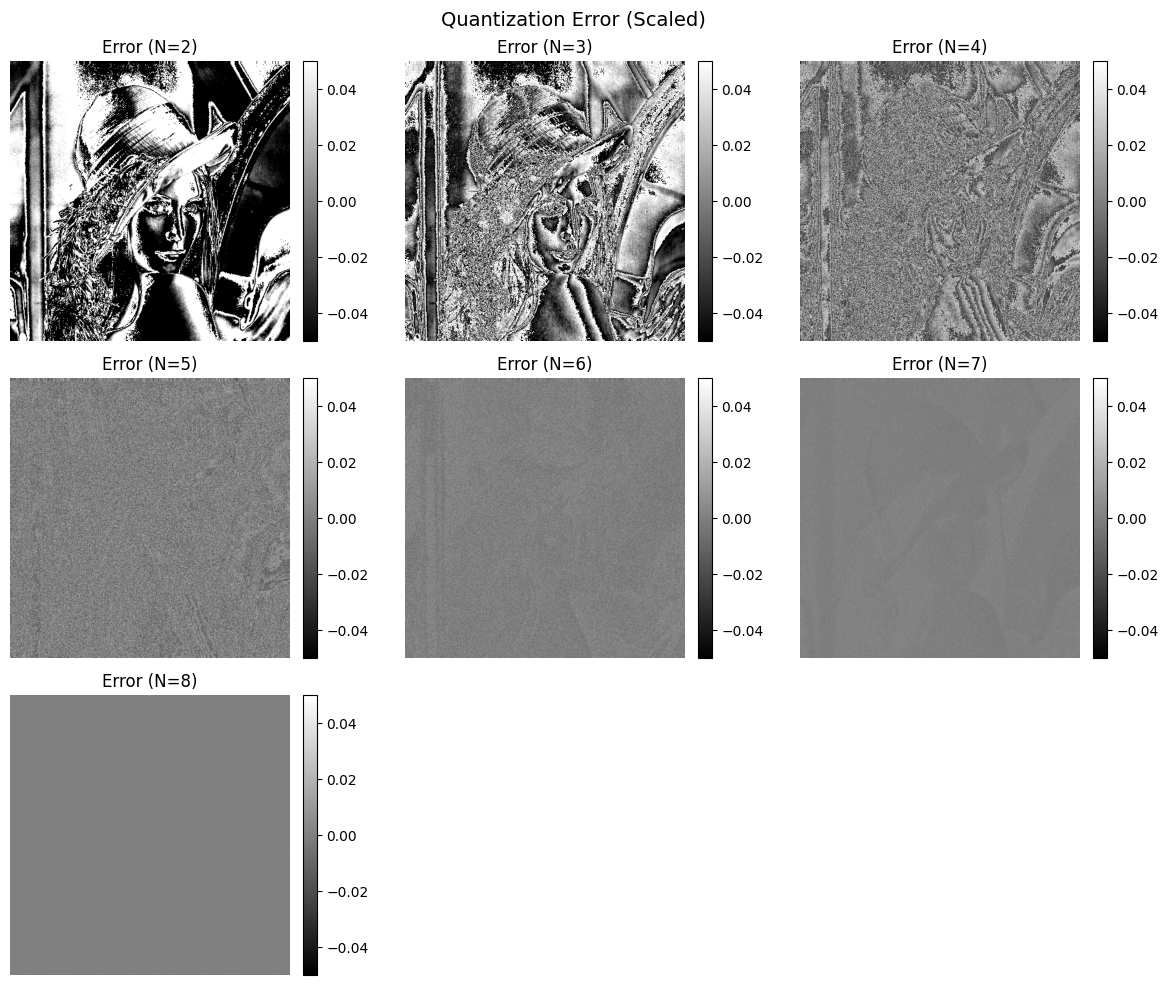


Linear model (polyfit): SNR = 6.69 * N + (1.31) dB
Slope ≈ 6.69 dB/bit (theoretical ≈ 6.02 dB/bit)


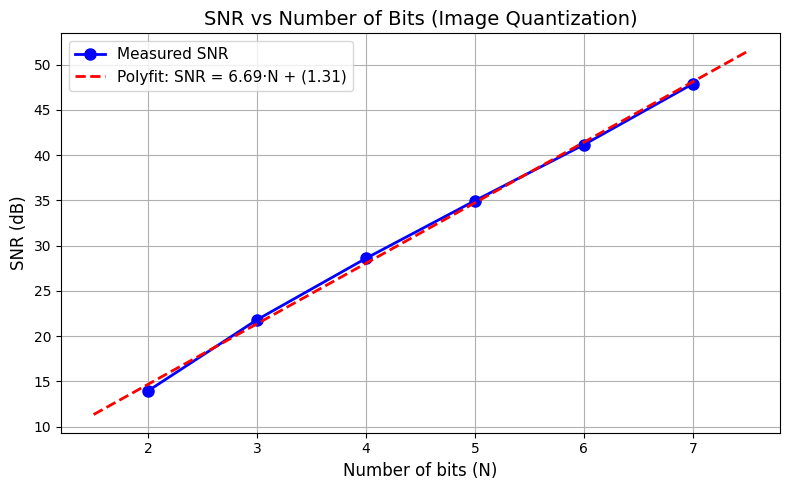

In [ ]:
#  (Q3 + Q4 )

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


img = Image.open('lena512.bmp').convert('L')
A = np.array(img, dtype=np.float32)


plt.figure()
plt.imshow(A, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')
plt.show()


A = A / 255.0


def quantize_image(image, N):
    L = 2**N
    return np.round(image * (L - 1)) / (L - 1)

def compute_snr(original, reconstructed):
    signal_power = np.mean(original**2)
    noise = original - reconstructed
    noise_power = np.mean(noise**2)
    if noise_power == 0:
        return np.inf
    return 10 * np.log10(signal_power / noise_power)


N_values = [2, 3, 4, 5, 6, 7, 8]
snr_values = []
quantized_images = {}

for N in N_values:
    Aq = quantize_image(A, N)
    snr = compute_snr(A, Aq)
    snr_values.append(snr)
    quantized_images[N] = Aq
    print(f"N={N}: SNR = {snr:.2f} dB")


plt.figure(figsize=(12, 10))
for i, N in enumerate(N_values):
    Aq_display = (quantized_images[N] * 255).astype(np.uint8)
    plt.subplot(3, 3, i+1)
    plt.imshow(Aq_display, cmap='gray', vmin=0, vmax=255)
    snr_str = f'{snr_values[i]:.2f}' if np.isfinite(snr_values[i]) else '∞'
    plt.title(f'N={N} bits\nSNR={snr_str} dB')
    plt.axis('off')

plt.suptitle('Quantized Images', fontsize=14)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 10))
for i, N in enumerate(N_values):
    error = A - quantized_images[N]
    plt.subplot(3, 3, i+1)
    im = plt.imshow(error, cmap='gray', vmin=-0.05, vmax=0.05)
    plt.title(f'Error (N={N})')
    plt.axis('off')
    plt.colorbar(im, fraction=0.046, pad=0.04)

plt.suptitle('Quantization Error (Scaled)', fontsize=14)
plt.tight_layout()
plt.show()


N_finite = [n for n, s in zip(N_values, snr_values) if np.isfinite(s)]
snr_finite = [s for s in snr_values if np.isfinite(s)]


a, b = np.polyfit(N_finite, snr_finite, 1)

print(f"\nLinear model (polyfit): SNR = {a:.2f} * N + ({b:.2f}) dB")
print(f"Slope ≈ {a:.2f} dB/bit (theoretical ≈ 6.02 dB/bit)")

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(N_finite, snr_finite, 'bo-', markersize=8, linewidth=2, label='Measured SNR')


if len(N_finite) < len(N_values):
    ax.annotate('N=8: SNR = ∞ (perfect reconstruction)',
                xy=(8, max(snr_finite)*0.95),
                fontsize=10, color='green',
                ha='right',
                arrowprops=dict(arrowstyle='->', color='green'))


N_fit = np.linspace(N_finite[0] - 0.5, N_finite[-1] + 0.5, 200)
snr_fit = a * N_fit + b
ax.plot(N_fit, snr_fit, 'r--', linewidth=2,
        label=f'Polyfit: SNR = {a:.2f}·N + ({b:.2f})')


ax.set_xlabel('Number of bits (N)', fontsize=12)
ax.set_ylabel('SNR (dB)', fontsize=12)
ax.set_title('SNR vs Number of Bits (Image Quantization)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

fig.tight_layout()
plt.show()

The image was converted to grayscale and normalized to the range [0, 1]. It was then quantized for bit depths from N = 2 to N = 8 using uniform quantization with rounding. For each case, the quantization error was computed, and the SNR was obtained as the ratio between the signal power and the error power in dB.

The results show that the SNR increases approximately linearly with the number of bits. A linear model obtained using polyfit (excluding N = 8, which yields infinite SNR) confirms this trend, with a slope close to the expected value of about 6 dB per bit. This indicates that each additional bit significantly reduces the quantization error.

From the visual analysis, the error is strongly structured at low bit depths and becomes weaker and more noise-like as N increases. A fixed display scale was used for all error images to allow a fair comparison of error magnitude across different values of N, avoiding misleading contrast differences due to automatic rescaling

Looking at the quantized images, the degradation is very clear at low bit depths. At N = 2, with only 4 grey levels, the image is reduced to something closer to a rough sketch, with harsh transitions between flat regions far from a natural photograph. At N = 3 (8 levels), there is some improvement, but the banding in smooth areas such as the background and skin is still very noticeable.

At N = 4, the image appears reasonable at first glance, but closer inspection reveals contouring in gradual intensity transitions, particularly around the hat and shoulder. These discontinuities between quantization levels are still clearly visible.

At N = 5 (32 levels), the contouring is no longer obvious under normal viewing conditions. The image looks clean overall, although faint artifacts can still be detected in the smoothest regions if examined carefully. For most practical purposes, this is where the quality becomes acceptable.

By N = 6, no visible artifacts could be identified, even when focusing on smooth gradients. The image appears indistinguishable from the original. Increasing the bit depth further (N = 7 and N = 8) does not produce any noticeable visual improvement.

Overall, the minimum number of bits depends on the level of strictness. A value of N = 5 bits is sufficient for visually acceptable, artifact-free viewing in typical conditions, while N = 6 bits provides a more conservative threshold where no degradation is perceptible even upon close inspection. This aligns with the observation that, at this point, the quantization error becomes small and largely noise-like, rather than structured and visually disturbing.